# Сравнение VI и PI для разных θ

1. Сначала в ноутбуке `asymptotics_vi_pi.ipynb` запускаются вычисления (для одного или нескольких значений θ) — в конце он сохраняет JSON `results_asymptotics_vi_pi_*.json`.
2. Затем этот ноутбук автоматически находит все такие JSON, читает из них θ и строит по одному графику VI и PI на каждый запуск (сабплоты по горизонтали). В конце сохраняются рисунки и агрегированный JSON.


In [1]:
import sys
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from contextlib import redirect_stdout
import os

# Настройка пути к корню проекта, как в asymptotics_vi_pi.ipynb
root = Path.cwd().parent if Path.cwd().name == "experiments" else Path.cwd()
sys.path.insert(0, str(root))

from src.environment import ParkourEnv
from src.algorithms import ValueIteration, PolicyIteration
from src.landscape import generate_height_map, build_graph, dijkstra

# Параметры эксперимента
THETAS = [0.1, 1e-3, 1e-6]
GAMMA = 0.99
MAX_JUMP_UP = 3
SAFE_JUMP_DOWN = 1
MIN_HEIGHT, MAX_HEIGHT = 1, 10
SEED_BASE = 42
MAX_GRID_SIZE = 50  # максимум размера сетки n (n×n)
N_MAPS = 10         # сколько карт на каждый размер сетки для усреднения времени

rewards = {"victory": 100, "death": -100, "step": -1}

all_data = []  # сюда собираем результаты для всех θ

for theta in THETAS:
    algo_config_vi = {"gamma": GAMMA, "theta": theta, "max_iters": 50000}
    algo_config_pi = {"gamma": GAMMA, "theta": theta, "max_eval_iters": 5000}

    results = []

    for grid_size in range(2, MAX_GRID_SIZE + 1):
        start = (0, 0)
        end = (grid_size - 1, grid_size - 1)
        times_vi, times_pi = [], []

        for map_idx in range(N_MAPS):
            attempt = 0
            while True:
                seed = SEED_BASE + grid_size * 10000 + map_idx * 1000 + attempt
                height_map = generate_height_map(grid_size, MIN_HEIGHT, MAX_HEIGHT, seed)
                graph = build_graph(height_map, MAX_JUMP_UP, SAFE_JUMP_DOWN)
                total_damage, path = dijkstra(graph, start, end)
                if path is not None and total_damage != float("inf"):
                    break
                attempt += 1

            hp_start = int(total_damage) + 1
            env_config = {
                "height_map": height_map.tolist(),
                "hp_start": hp_start,
                "rewards": rewards,
                "max_jump_up": MAX_JUMP_UP,
                "safe_jump_down": SAFE_JUMP_DOWN,
            }

            env = ParkourEnv(env_config)
            n_states = env.rows * env.cols * (env.hp_start + 1)

            algo_vi = ValueIteration(env, algo_config_vi)
            with open(os.devnull, "w") as fnull, redirect_stdout(fnull):
                info_vi = algo_vi.solve()
            times_vi.append(info_vi["time"])

            env2 = ParkourEnv(env_config)
            algo_pi = PolicyIteration(env2, algo_config_pi)
            with open(os.devnull, "w") as fnull, redirect_stdout(fnull):
                info_pi = algo_pi.solve()
            times_pi.append(info_pi["time"])

        time_vi_mean = np.mean(times_vi)
        time_pi_mean = np.mean(times_pi)
        time_vi_std = np.std(times_vi)
        time_pi_std = np.std(times_pi)

        results.append({
            "grid_size": grid_size,
            "n_states": n_states,
            "min_damage": total_damage,
            "hp_start": hp_start,
            "time_vi": float(time_vi_mean),
            "time_pi": float(time_pi_mean),
            "time_vi_std": float(time_vi_std),
            "time_pi_std": float(time_pi_std),
        })
        print(f"θ={theta}, grid {grid_size}x{grid_size}: {N_MAPS} maps, VI={time_vi_mean:.4f}s ± {time_vi_std:.4f}, PI={time_pi_mean:.4f}s ± {time_pi_std:.4f}")

    all_data.append({
        "label": f"θ = {theta}",
        "theta": theta,
        "n_maps": N_MAPS,
        "results": results,
    })

print("Всего запусков:", len(all_data))
for d in all_data:
    print(f"  {d['label']}: points={len(d['results'])}")


/Users/vasilij/Documents/RL_proj3/Parkour/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  1%|▏         | 688/50000 [00:00<00:00, 126348.84it/s]
2it [00:00, 428.27it/s, delta=9.64e-02]
  1%|▏         | 688/50000 [00:00<00:00, 128263.90it/s]
3it [00:00, 66.97it/s, delta=9.63e-02] 
  1%|▏         | 688/50000 [00:00<00:03, 16064.67it/s]
3it [00:00, 395.71it/s, delta=9.44e-02]
  1%|▏         | 688/50000 [00:00<00:00, 106075.62it/s]
2it [00:00, 121.54it/s, delta=9.64e-02]
  1%|▏         | 688/50000 [00:00<00:00, 79070.59it/s]
3it [00:00, 375.27it/s, delta=9.54e-02]
  1%|▏         | 688/50000 [00:00<00:00, 117146.96it/s]
3it [00:00, 495.04it/s, delta=9.35e-02]
  1%|▏         | 688/50000 [00:00<00:00, 106138.04it/s]
3it [00:00, 129.13it/s, delta=9.72e-02]
  1%|▏         | 688/50000 [00:00<00:01, 43796.7

θ=0.1, grid 2x2: 10 maps, VI=0.0191s ± 0.0243, PI=0.0196s ± 0.0116


5it [00:00, 293.06it/s, delta=9.25e-02]
  1%|▏         | 688/50000 [00:00<00:00, 59685.64it/s]
5it [00:00, 363.88it/s, delta=9.25e-02]
  1%|▏         | 688/50000 [00:00<00:00, 105706.48it/s]
4it [00:00, 315.63it/s, delta=9.44e-02]
  1%|▏         | 688/50000 [00:00<00:00, 106404.17it/s]
4it [00:00, 334.78it/s, delta=9.44e-02]
  1%|▏         | 688/50000 [00:00<00:00, 73834.69it/s]
3it [00:00, 302.26it/s, delta=9.26e-02]
  1%|▏         | 688/50000 [00:00<00:00, 58602.03it/s]
6it [00:00, 414.73it/s, delta=8.97e-02]
  1%|▏         | 688/50000 [00:00<00:00, 73262.95it/s]
7it [00:00, 685.01it/s, delta=8.71e-02]
  1%|▏         | 688/50000 [00:00<00:00, 101248.42it/s]
8it [00:00, 511.38it/s, delta=8.62e-02]
  1%|▏         | 688/50000 [00:00<00:00, 64006.77it/s]
7it [00:00, 565.48it/s, delta=8.71e-02]
  1%|▏         | 688/50000 [00:00<00:00, 92712.65it/s]
6it [00:00, 302.30it/s, delta=8.88e-02]
  1%|▏         | 688/50000 [00:00<00:00, 75338.25it/s]
7it [00:00, 345.90it/s, delta=8.79e-02]
  1%|▏ 

θ=0.1, grid 3x3: 10 maps, VI=0.0118s ± 0.0033, PI=0.0168s ± 0.0051


7it [00:00, 321.78it/s, delta=8.79e-02]
  1%|▏         | 688/50000 [00:00<00:00, 100848.58it/s]
6it [00:00, 309.03it/s, delta=8.97e-02]
  1%|▏         | 688/50000 [00:00<00:00, 74212.56it/s]
6it [00:00, 483.68it/s, delta=8.45e-02]
  1%|▏         | 688/50000 [00:00<00:00, 79851.71it/s]
10it [00:00, 605.76it/s, delta=4.07e-05]
  1%|▏         | 688/50000 [00:00<00:01, 46308.71it/s]
9it [00:00, 511.94it/s, delta=4.14e-02]
  1%|▏         | 688/50000 [00:00<00:00, 63649.58it/s]
9it [00:00, 307.95it/s, delta=7.87e-02]
  1%|▏         | 688/50000 [00:00<00:00, 91524.66it/s]
8it [00:00, 518.70it/s, delta=8.62e-02]
  1%|▏         | 688/50000 [00:00<00:00, 83120.12it/s]
9it [00:00, 827.21it/s, delta=8.36e-02]
  1%|▏         | 688/50000 [00:00<00:00, 118518.20it/s]
9it [00:00, 1000.13it/s, delta=8.45e-02]
  1%|▏         | 688/50000 [00:00<00:00, 56108.91it/s]
7it [00:00, 660.68it/s, delta=8.28e-02]
  1%|▏         | 688/50000 [00:00<00:00, 132486.16it/s]
4it [00:00, 418.20it/s, delta=1.94e+02]

...

θ=1e-06, grid 48x48: 10 maps, VI=2.3562s ± 0.4077, PI=1.7499s ± 1.3181


  4%|▎         | 1833/50000 [00:02<00:53, 895.43it/s]
121it [00:01, 73.58it/s, delta=5.50e-09] 
  4%|▎         | 1833/50000 [00:01<00:51, 943.47it/s]
114it [00:01, 99.45it/s, delta=4.28e-09] 
  4%|▎         | 1833/50000 [00:02<00:59, 805.24it/s]
107it [00:01, 72.47it/s, delta=9.51e-09] 
  4%|▎         | 1833/50000 [00:01<00:47, 1021.64it/s]
108it [00:01, 103.27it/s, delta=6.66e-09]
  4%|▎         | 1833/50000 [00:01<00:49, 978.80it/s]
99it [00:01, 85.61it/s, delta=6.02e-09] 
  4%|▎         | 1833/50000 [00:02<00:55, 860.72it/s]
1398it [00:04, 305.51it/s, delta=0.00e+00]
  4%|▎         | 1833/50000 [00:03<01:19, 605.94it/s]
110it [00:01, 65.31it/s, delta=7.22e-09] 
  4%|▎         | 1833/50000 [00:03<01:25, 560.14it/s]
120it [00:01, 63.75it/s, delta=2.44e-09] 
  4%|▎         | 1833/50000 [00:03<01:19, 609.39it/s]
98it [00:01, 59.19it/s, delta=5.61e-09]
  4%|▎         | 1833/50000 [00:02<01:09, 697.40it/s]
111it [00:01, 74.98it/s, delta=5.08e-09] 


θ=1e-06, grid 49x49: 10 maps, VI=2.4006s ± 0.5139, PI=1.7756s ± 0.9686


  4%|▎         | 1833/50000 [00:02<01:09, 696.14it/s]
118it [00:01, 73.42it/s, delta=5.18e-09] 
  4%|▎         | 1833/50000 [00:02<01:11, 673.08it/s]
114it [00:01, 74.11it/s, delta=5.39e-09] 
  4%|▎         | 1833/50000 [00:02<01:02, 768.05it/s]
106it [00:01, 78.43it/s, delta=4.41e-09] 
  4%|▎         | 1833/50000 [00:03<01:21, 590.61it/s]
114it [00:01, 67.74it/s, delta=2.72e-09] 
  4%|▎         | 1833/50000 [00:02<01:11, 670.87it/s]
105it [00:01, 69.64it/s, delta=6.72e-09] 
  4%|▎         | 1833/50000 [00:02<01:09, 696.84it/s]
112it [00:01, 68.04it/s, delta=2.32e-09] 
  4%|▎         | 1833/50000 [00:02<01:02, 767.26it/s]
1368it [00:05, 259.75it/s, delta=0.00e+00]
  4%|▎         | 1833/50000 [00:02<01:07, 716.37it/s]
109it [00:01, 74.69it/s, delta=3.43e-09] 
  4%|▎         | 1833/50000 [00:02<01:13, 653.76it/s]
112it [00:02, 53.35it/s, delta=0.00e+00] 
  4%|▎         | 1833/50000 [00:02<01:07, 714.02it/s]
109it [00:01, 74.69it/s, delta=4.73e-09] 

θ=1e-06, grid 50x50: 10 maps, VI=2.6537s ± 0.1987, PI=1.9625s ± 1.1183
Всего запусков: 3
  θ = 0.1: points=49
  θ = 0.001: points=49
  θ = 1e-06: points=49


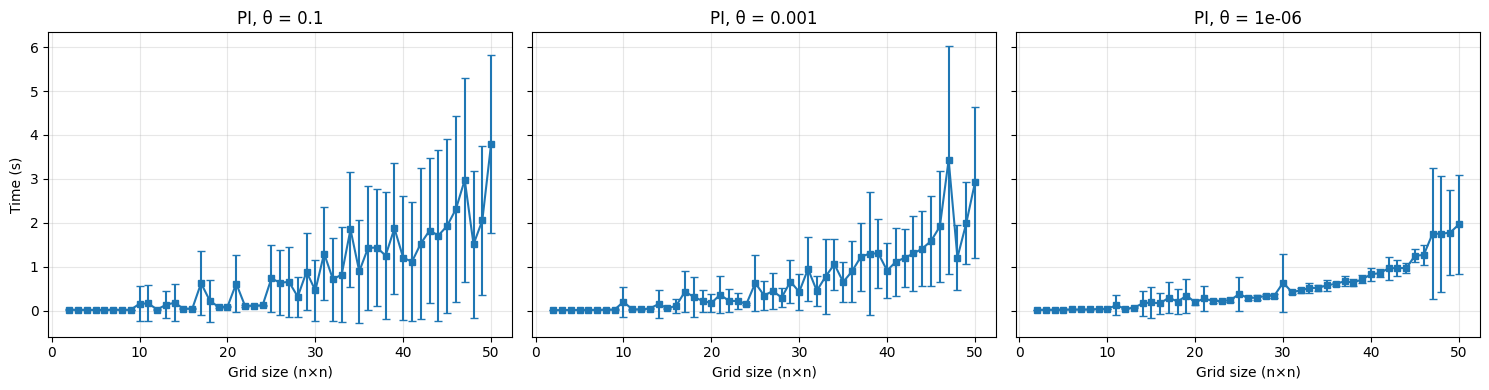

In [2]:
# 3 графика PI по горизонтали
fig_pi, axes_pi = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, d in zip(axes_pi, all_data):
    label = d["label"]
    results = d["results"]

    grid_sizes = [r["grid_size"] for r in results]
    time_pi = [r["time_pi"] for r in results]
    time_pi_std = [r.get("time_pi_std", 0.0) for r in results]

    ax.errorbar(
        grid_sizes,
        time_pi,
        yerr=time_pi_std,
        fmt="s-",
        markersize=5,
        capsize=3,
        label="PI",
    )
    ax.set_title(f"PI, {label}")
    ax.set_xlabel("Grid size (n×n)")
    ax.grid(True, alpha=0.3)

axes_pi[0].set_ylabel("Time (s)")
plt.tight_layout()
plt.show()


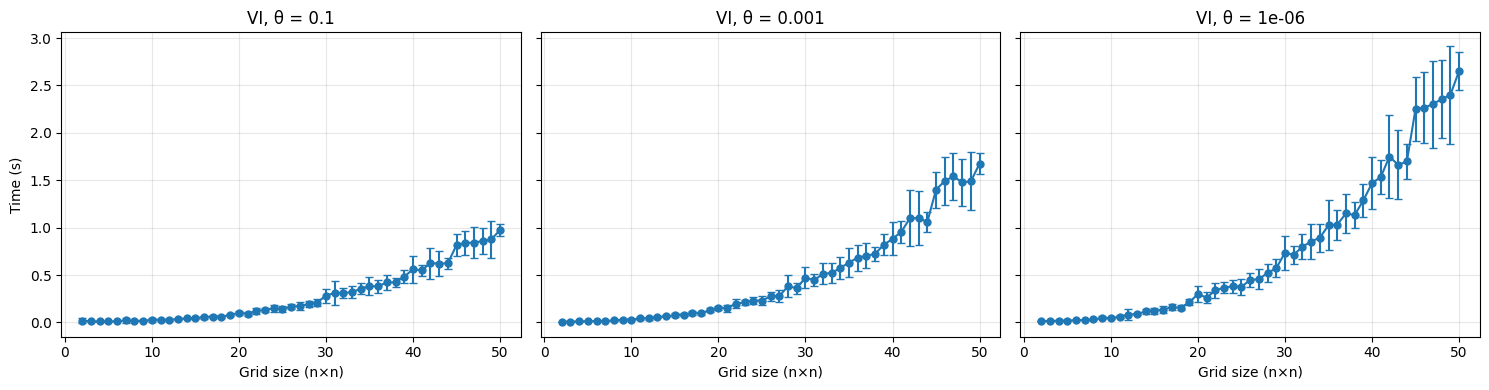

In [3]:
# 3 графика VI по горизонтали
fig_vi, axes_vi = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, d in zip(axes_vi, all_data):
    label = d["label"]
    results = d["results"]

    grid_sizes = [r["grid_size"] for r in results]
    time_vi = [r["time_vi"] for r in results]
    time_vi_std = [r.get("time_vi_std", 0.0) for r in results]

    ax.errorbar(
        grid_sizes,
        time_vi,
        yerr=time_vi_std,
        fmt="o-",
        markersize=5,
        capsize=3,
        label="VI",
    )
    ax.set_title(f"VI, {label}")
    ax.set_xlabel("Grid size (n×n)")
    ax.grid(True, alpha=0.3)

axes_vi[0].set_ylabel("Time (s)")
plt.tight_layout()
plt.show()


In [4]:
# Сохранение объединённых результатов и графиков

from pathlib import Path
BASE_DIR = Path.cwd()
RESULTS_JSON_DIR = BASE_DIR / "results" / "json"
RESULTS_IMG_DIR = BASE_DIR / "results" / "img"
RESULTS_JSON_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_IMG_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Сохраняем агрегированные данные
out_json = RESULTS_JSON_DIR / f"compare_thetas_vi_pi_{timestamp}.json"
with open(out_json, "w", encoding="utf-8") as f:
    json.dump({"runs": all_data}, f, indent=2)

# Сохраняем последние построенные фигуры (VI и PI)
pi_png = RESULTS_IMG_DIR / f"compare_thetas_PI_{timestamp}.png"
vi_png = RESULTS_IMG_DIR / f"compare_thetas_VI_{timestamp}.png"
fig_pi.savefig(pi_png, dpi=150, bbox_inches="tight")
fig_vi.savefig(vi_png, dpi=150, bbox_inches="tight")

print("Сохранены файлы:")
print("  ", out_json)
print("  ", pi_png)
print("  ", vi_png)


Сохранены файлы:
   /Users/vasilij/Documents/RL_proj3/Parkour/experiments/results/json/compare_thetas_vi_pi_2026-03-16_13-07-05.json
   /Users/vasilij/Documents/RL_proj3/Parkour/experiments/results/img/compare_thetas_PI_2026-03-16_13-07-05.png
   /Users/vasilij/Documents/RL_proj3/Parkour/experiments/results/img/compare_thetas_VI_2026-03-16_13-07-05.png
